In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
# Config
pd.set_option("display.max_columns", None)
sns.set_theme(style="darkgrid")

# Load data
data = pd.read_csv("Linhac24-25_Sportlogiq.csv")

# Overview
print(data.shape)
print(data.dtypes)
print(data.describe())
print(data.isnull().sum())

data.head(10)

(541802, 22)
gameid                             int64
opposingteamgoalieoniceid        float64
opposingteamid                     int64
playerid                           int64
teamgoalieoniceid                float64
teamid                             int64
teaminpossession                 float64
currentpossession                float64
xg_allattempts                   float64
compiledgametime                 float64
eventname                         object
ishomegame                         int64
manpowersituation                 object
opposingteamskatersonicecount      int64
outcome                           object
period                             int64
playerprimaryposition             object
scoredifferential                  int64
teamskatersonicecount              int64
type                              object
xadjcoord                        float64
yadjcoord                        float64
dtype: object
              gameid  opposingteamgoalieoniceid  opposingteamid  \
coun

,gameid,opposingteamgoalieoniceid,opposingteamid,playerid,teamgoalieoniceid,teamid,teaminpossession,currentpossession,xg_allattempts,compiledgametime,eventname,ishomegame,manpowersituation,opposingteamskatersonicecount,outcome,period,playerprimaryposition,scoredifferential,teamskatersonicecount,type,xadjcoord,yadjcoord
0,72393,553243.0,885,489917,172367.0,814,NaN,NaN,NaN,0.000000,faceoff,1,evenStrength,5,failed,1,F,0,5,none,0.304306,0.251442
1,72393,172367.0,814,435025,553243.0,885,NaN,NaN,NaN,0.000000,faceoff,0,evenStrength,5,successful,1,F,0,5,recovered,-0.304306,-0.251442
2,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,1.333333,lpr,0,evenStrength,5,successful,1,F,0,5,faceoffcontested,0.205826,0.245975
3,72393,553243.0,885,489917,172367.0,814,885.0,0.0,NaN,1.333333,lpr,1,evenStrength,5,failed,1,F,0,5,contested,-0.205826,-0.245975
4,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,2.166667,pass,0,evenStrength,5,successful,1,F,0,5,south,3.223473,3.766563
5,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,2.966667,reception,0,evenStrength,5,successful,1,D,0,5,regular,-19.911827,11.310680
6,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,4.466667,pass,0,evenStrength,5,failed,1,D,0,5,north,-7.338295,26.398914
7,72393,553243.0,885,213380,172367.0,814,885.0,0.0,NaN,4.700000,block,1,evenStrength,5,successful,1,F,0,5,pass,1.813835,-24.897058
8,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.033333,lpr,1,evenStrength,5,successful,1,F,0,5,none,-17.800873,-40.991177
9,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.533333,puckprotection,1,evenStrength,5,successful,1,F,0,5,body,-16.794991,-40.488235


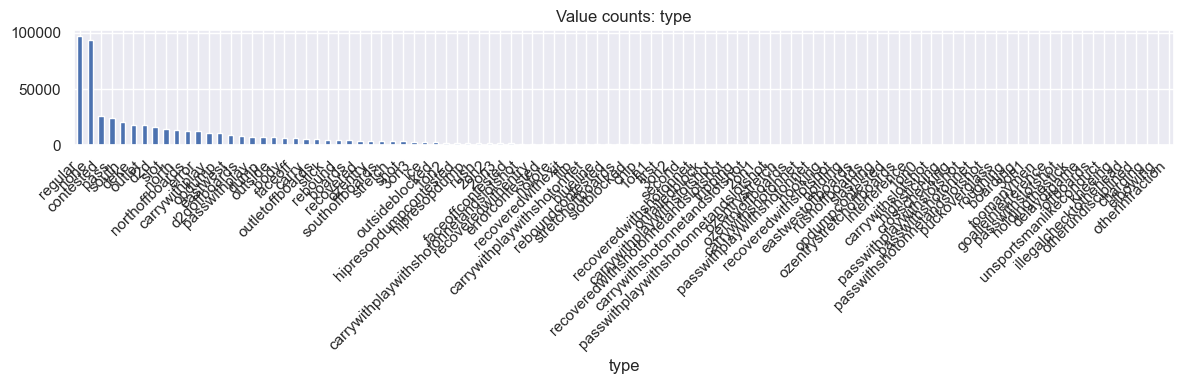

In [56]:
# Distributions of column type 
col = "type"

data[col].value_counts().plot(kind="bar", figsize=(12, 4))
plt.title(f"Value counts: {col}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

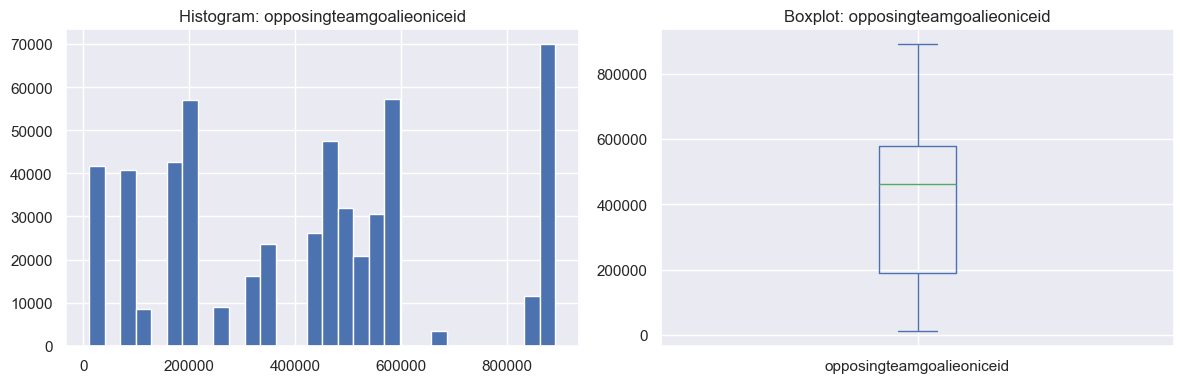

In [57]:
# Distributions of column opposingteamgoalieoniceid 
col = "opposingteamgoalieoniceid"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data[col].hist(bins=30, ax=axes[0])
axes[0].set_title(f"Histogram: {col}")
data[col].plot(kind="box", ax=axes[1])
axes[1].set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

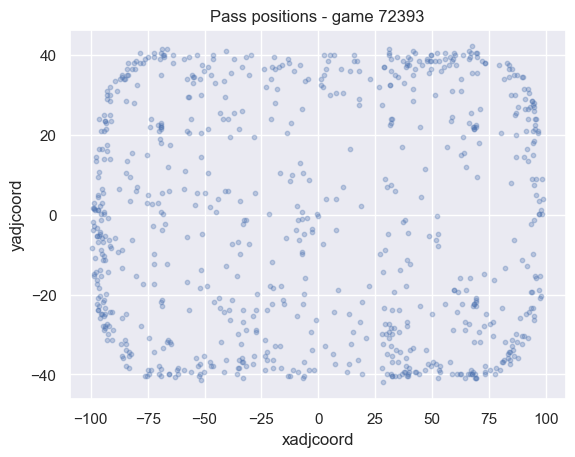

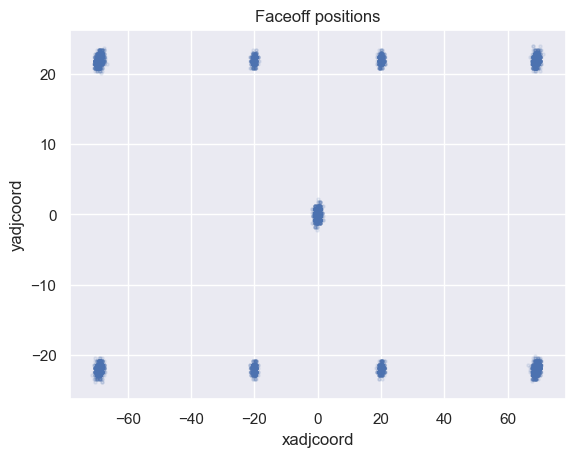

In [58]:
# Plot passes
passes = data[(data['eventname'] == 'pass') & (data['gameid'] == 72393)]
plt.scatter(passes['xadjcoord'], passes['yadjcoord'], alpha=0.3, s=10)
plt.title('Pass positions - game 72393')
plt.xlabel('xadjcoord')
plt.ylabel('yadjcoord')
plt.show()

# Plot faceoffs
faceoffs = data[data['eventname'] == 'faceoff']
plt.scatter(faceoffs['xadjcoord'], faceoffs['yadjcoord'], alpha=0.1, s=5)
plt.title('Faceoff positions')
plt.xlabel('xadjcoord')
plt.ylabel('yadjcoord')
plt.show()

In [59]:
# Alla som har controlledentry till andra zonen och alla typer hur entryn har gjorts
data[data['eventname'] == 'controlledentry']['type'].value_counts()

# Sannolikheten att ett skott resulterar i ett mål
data['xg_allattempts']

# Alla händelser som har mer än 80 % sannolikhet att bli mål 
data[data['xg_allattempts'] > 0.8][['eventname', 'xg_allattempts', 'xadjcoord', 'yadjcoord']]

,eventname,xg_allattempts,xadjcoord,yadjcoord
53328,shot,0.810006,-58.539108,38.976471
313148,shot,0.949455,-90.331482,-30.929413
326988,shot,0.882324,82.177345,-3.267647
399178,shot,0.805608,-40.032639,-40.485291
437140,shot,0.805782,-82.284424,37.973530
496175,shot,0.896192,84.692047,1.258823
538756,shot,0.809618,85.805008,-1.761765


In [60]:
data[data['eventname'] == 'controlledentry']['type'].value_counts()

type
carry                                    3755
carrywithplay                            2396
carrywithplaywithshotonnetandslotshot    1497
pass                                     1448
carrywithplaywithshotonnet               1327
carrywithplaywithslotshot                 410
passwithplay                              357
carrywithshotonnetandslotshot             354
passwithplaywithshotonnetandslotshot      316
carrywithshotonnet                        273
passwithplaywithshotonnet                 255
carrywithslotshot                         121
passwithplaywithslotshot                   73
passwithshotonnet                          60
passwithshotonnetandslotshot               60
passwithslotshot                           24
Name: count, dtype: int64

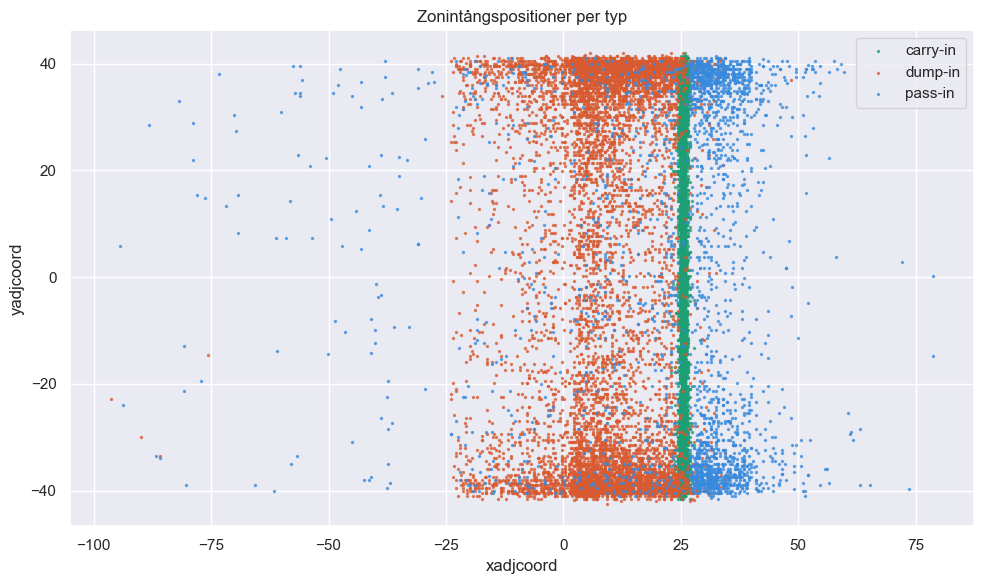

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("Linhac24-25_Sportlogiq.csv")

# Klassificera ingångstyp
def classify_entry(row):
    if 'dumpin' in str(row['eventname']).lower():
        return 'dump-in'
    elif 'controlledentry' in str(row['eventname']).lower():
        if 'carry' in str(row['type']).lower():
            return 'carry-in'
        elif 'pass' in str(row['type']).lower():
            return 'pass-in'
    return None

data['entry_type'] = data.apply(classify_entry, axis=1)
entries = data[data['entry_type'].notna()].copy()

colors = {'carry-in': '#1D9E75', 'pass-in': '#378ADD', 'dump-in': '#D85A30'}

fig, ax = plt.subplots(figsize=(10, 6))

for etype, group in entries.groupby('entry_type'):
    ax.scatter(group['xadjcoord'], group['yadjcoord'],
               c=colors[etype], alpha=0.7, s=2, label=etype)

ax.set_title('Zonintångspositioner per typ')
ax.set_xlabel('xadjcoord')
ax.set_ylabel('yadjcoord')
ax.legend()
plt.tight_layout()
plt.show()

### Trötthet

In [ ]:
# ----- Markera när en spelare bytt av och kommit tillbaka -----
# Gap över 30s = nytt byte
data = data.sort_values(['playerid', 'gameid', 'compiledgametime']).reset_index(drop=True)
data['event_gap'] = data.groupby(['playerid', 'gameid'])['compiledgametime'].diff()
data['new_shift'] = (data['event_gap'] > 60) | (data['event_gap'].isna())

# Varje byte får unikt ID per spelare och match
data['shift_id'] = data.groupby(['playerid', 'gameid'])['new_shift'].cumsum()

# Kontroll för en spelare
example_player = data['playerid'].iloc[0]
example_game = data['gameid'].iloc[0]

mask = (data['playerid'] == example_player) & (data['gameid'] == example_game)
print(data[mask][['compiledgametime', 'eventname', 'event_gap', 'new_shift', 'shift_id']].head(30).to_string())

    compiledgametime       eventname  event_gap  new_shift  shift_id
0              51.32             lpr        NaN       True         1
1              52.56            pass       1.24      False         1
2              67.28       reception      14.72      False         1
3              70.68            pass       3.40      False         1
4              72.92       reception       2.24      False         1
5              73.56  puckprotection       0.64      False         1
6             432.60       reception     359.04       True         2
7             432.64          assist       0.04      False         2
8             603.12       reception     170.48       True         3
9             603.72           carry       0.60      False         3
10            604.08  puckprotection       0.36      False         3
11            606.52            pass       2.44      False         3
12            998.44             lpr     391.92       True         4
13            999.32  puckprotecti

In [89]:
# Tid fårn bytets start till ett event spelaren gör 
# Första eventet i varje byte får time_into_shift = 0
shift_start = data.groupby(['playerid', 'gameid', 'shift_id'])['compiledgametime'].transform('min')
data['time_into_shift'] = data['compiledgametime'] - shift_start

# Kontroll av en spelare
mask = (data['playerid'] == example_player) & (data['gameid'] == example_game)
print(data[mask][['compiledgametime', 'eventname', 'shift_id', 'time_into_shift']].to_string())

    compiledgametime       eventname  shift_id  time_into_shift
0              51.32             lpr         1             0.00
1              52.56            pass         1             1.24
2              67.28       reception         1            15.96
3              70.68            pass         1            19.36
4              72.92       reception         1            21.60
5              73.56  puckprotection         1            22.24
6             432.60       reception         2             0.00
7             432.64          assist         2             0.04
8             603.12       reception         3             0.00
9             603.72           carry         3             0.60
10            604.08  puckprotection         3             0.96
11            606.52            pass         3             3.40
12            998.44             lpr         4             0.00
13            999.32  puckprotection         4             0.88
14           1001.68             lpr    

------------------------------

In [86]:
# Sortera så att spelarens events ligger i rätt tidsordning
data = data.sort_values(['playerid', 'gameid', 'compiledgametime']).reset_index(drop=True)

# Kontroll för första spelaren i datan
example_player = data['playerid'].iloc[0]
example_game = data['gameid'].iloc[0]

mask = (data['playerid'] == example_player) & (data['gameid'] == example_game)
#rint(data[mask][['playerid', 'gameid', 'compiledgametime', 'eventname']].head(20).to_string())

In [87]:
# Beräkna tid sedan spelarens förra event i samma match
# (NaN på första eventet per spelare och match)
data['event_gap'] = data.groupby(['playerid', 'gameid'])['compiledgametime'].diff()

# Kontroll
example_player = data['playerid'].iloc[0]
example_game = data['gameid'].iloc[0]

mask = (data['playerid'] == example_player) & (data['gameid'] == example_game)
#print(data[mask][['compiledgametime', 'eventname', 'event_gap']].head(20).to_string())

In [64]:
# Lägg till event_gap på zonintångsdatan
# Merga på playerid, gameid och exakt tidpunkt
entries = entries.merge(
    data[['playerid', 'gameid', 'compiledgametime', 'event_gap']],
    on=['playerid', 'gameid', 'compiledgametime'],
    how='left'
)

# Ta bort dubletter i data och entries
data = data.drop_duplicates(subset=['playerid', 'gameid', 'compiledgametime']).reset_index(drop=True)
entries = entries.drop_duplicates(subset=['playerid', 'gameid', 'compiledgametime']).reset_index(drop=True)

# Kontroll
print(f"Rader i data: {len(data)}")
print(f"Rader i entries: {len(entries)}")
print(entries[['playerid', 'gameid', 'compiledgametime', 'eventname', 'entry_type', 'event_gap']].head(10).to_string())

Rader i data: 499194
Rader i entries: 21296
   playerid  gameid  compiledgametime        eventname entry_type  event_gap
0    213380   72393         12.433333  controlledentry   carry-in   0.500000
1    435025   72393         17.000000  controlledentry    pass-in   0.766666
2    879732   72393         44.866665           dumpin    dump-in   1.299999
3    710249   72393         59.133335  controlledentry    pass-in   6.333335
4    376368   72393         94.433334  controlledentry   carry-in   1.099998
5    879732   72393        107.766670  controlledentry   carry-in   1.100006
6    307447   72393        127.333336  controlledentry   carry-in   0.266670
7    727892   72393        169.533340  controlledentry    pass-in   6.633340
8    834804   72393        200.666670  controlledentry   carry-in   0.800000
9    155992   72393        210.166670           dumpin    dump-in   0.033340


In [75]:
# Kort gap = spelaren är troligen trött (aktiv på isen)
# Långt gap = spelaren har troligen bytt av och vilat
entries['fatigue_category'] = pd.cut(
    entries['event_gap'],
    bins=[-1, 5, 45, 120, 9999],
    labels=['active', 'tired', 'rested', 'long_rest']
)

# Kontroll
print(entries['fatigue_category'].value_counts())

fatigue_category
active       19629
tired          800
long_rest      654
rested         163
Name: count, dtype: int64


------------------------------------------------

In [66]:
# Hitta tiden det tog sedan förra eventet för en spelare
data = data.sort_values(['playerid', 'gameid', 'compiledgametime']).reset_index(drop=True)
data['event_gap'] = data.groupby(['playerid', 'gameid'])['compiledgametime'].diff() # Diff mellan förgående värde och nu

# 
data = data.sort_values(['gameid', 'compiledgametime']).reset_index(drop=True)


In [67]:
# Hitta tiden det tog sedan förra eventet för en spelare
data = data.sort_values(['playerid', 'gameid', 'compiledgametime']).reset_index(drop=True)

# Beräkna hur lång tid det gått sedan spelarens förra event i samma match
# Kort gap = aktiv/trött, långt gap = avbytt och vilat
data['event_gap'] = data.groupby(['playerid', 'gameid'])['compiledgametime'].diff()

# Sortera kronologiskt per match
data = data.sort_values(['gameid', 'compiledgametime']).reset_index(drop=True)

# Beräkna hur många farliga situationer (mätt i xG) spelaren varit inblandad i senaste 60 sekunderna
# Högt värde = intensivt skift, lågt värde = lugnt skift
# OBS: xG finns bara på skott så de flesta spelare får 0 även på aktiva skift
def calculate_shift_intensity(df, time_window_seconds=60):
    result = []
    for (player_id, game_id), group in df.groupby(['playerid', 'gameid']):
        group = group.sort_values('compiledgametime')
        intensity = []
        for idx, row in group.iterrows():
            # Hämta alla events för spelaren inom tidsfönstret innan detta event
            recent_events = group[
                (group['compiledgametime'] >= row['compiledgametime'] - time_window_seconds) &
                (group['compiledgametime'] < row['compiledgametime'])
            ]
            intensity.append(recent_events['xg_allattempts'].fillna(0).sum())
        group = group.copy()
        group['shift_intensity'] = intensity
        result.append(group)
    return pd.concat(result)

data = calculate_shift_intensity(data, time_window_seconds=60)

# Lägg till trötthetsvariablerna på zonintångsdatan
entries = entries.merge(
    data[['playerid', 'gameid', 'compiledgametime', 'event_gap', 'shift_intensity']],
    on=['playerid', 'gameid', 'compiledgametime'],
    how='left'
)

print(entries[['event_gap', 'shift_intensity']].describe())

KeyboardInterrupt: 

In [ ]:
entries['fatigue_category'] = pd.cut(
    entries['event_gap'],
    bins=[-1, 5, 30, 120, 9999],
    labels=['ej_tolkningsbart', 'trott', 'normal_vila', 'lång_vila']
)

print(entries['fatigue_category'].value_counts())

fatigue_category
ej_tolkningsbart    57372
trott                1564
lång_vila            1386
normal_vila           486
Name: count, dtype: int64


In [ ]:
# Hitta tiden det tog sedan förra eventet för en spelare
data = data.sort_values(['playerid', 'gameid', 'compiledgametime']).reset_index(drop=True)

# Beräkna hur lång tid det gått sedan spelarens förra event i samma match
# Kort gap = aktiv/trött, långt gap = avbytt och vilat
data['event_gap'] = data.groupby(['playerid', 'gameid'])['compiledgametime'].diff()

# Kolla hur många entries som har rimliga gap (över 5 sekunder)
print(f"Totalt antal entries: {len(entries)}")
print(f"Gap under 5s: {(entries['event_gap'] <= 5).sum()}")
print(f"Gap över 5s: {(entries['event_gap'] > 5).sum()}")
print(f"Gap över 15s: {(entries['event_gap'] > 15).sum()}")
print(f"Gap över 30s: {(entries['event_gap'] > 30).sum()}")

# Fördelning av gap över 5s
entries[entries['event_gap'] > 5]['event_gap'].describe()

Totalt antal entries: 60915
Gap under 5s: 57372
Gap över 5s: 3436
Gap över 15s: 2535
Gap över 30s: 1872


count    3436.000000
mean      110.798051
std       135.123220
min         5.120000
25%        14.266640
50%        48.763350
75%       172.250000
max      1469.480000
Name: event_gap, dtype: float64

In [ ]:
mask = (data['playerid'] == example_player) & (data['gameid'] == example_game)
subset = data[mask][['compiledgametime', 'eventname', 'event_gap', 'entry_type']]

# Visa bara rader nära ett zonintång
print(subset[subset['entry_type'].notna() | subset['event_gap'] > 10].head(30).to_string())

Empty DataFrame
Columns: [compiledgametime, eventname, event_gap, entry_type]
Index: []


In [ ]:
# Hämta en spelare som har zonintång
example_player = entries['playerid'].iloc[0]
example_game = entries['gameid'].iloc[0]

print(f"Spelare: {example_player}, Match: {example_game}")

mask = (data['playerid'] == example_player) & (data['gameid'] == example_game)
subset = data[mask][['compiledgametime', 'eventname', 'event_gap', 'entry_type']]

print(subset.head(40).to_string())

Spelare: 213380, Match: 72393
       compiledgametime        eventname   event_gap entry_type
93772          4.700000            block         NaN       None
93773          6.033333              lpr    1.333333       None
93774          6.533333   puckprotection    0.500000       None
93775          8.500000            carry    1.966667       None
93776          9.066667   puckprotection    0.566667       None
93777         11.933333              lpr    2.866666       None
93778         12.433333            carry    0.500000       None
93779         12.433333  controlledentry    0.000000   carry-in
93780         13.266666   puckprotection    0.833333       None
93781         52.433334        reception   39.166668       None
93782        216.533340              lpr  164.100006       None
93783        216.900000             pass    0.366660       None
93784        223.266660        reception    6.366660       None
93785        224.033340            carry    0.766680       None
93786     